# 06 - Regresion: pronostico de ventas

Objetivo: construir y evaluar modelos de regresion para pronosticar ventas diarias de AndesMarket, respetando el orden temporal y generando salidas para Power BI.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
IMG = ROOT / 'informe' / 'img'
IMG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Variable objetivo

La variable objetivo es la venta diaria agregada (`ventas`). Se trabaja a nivel dia porque permite capturar estacionalidad semanal, meses fuertes y rezagos.

In [2]:
fact = pd.read_csv(DATA / 'fact_ventas.csv', sep=';', parse_dates=['fecha'])

diario = (
    fact.groupby('fecha')
        .agg(
            ventas=('importe', 'sum'),
            demanda=('cantidad', 'sum'),
            pct_lineas_promocion=('id_promocion', lambda s: (s != 'PR000').mean()),
            boletas=('id_venta', 'nunique'),
        )
        .asfreq('D')
        .fillna(0)
        .reset_index()
)

diario.head()

,fecha,ventas,demanda,pct_lineas_promocion,boletas
0,2024-01-01,4066.128,189,0.304878,82
1,2024-01-02,2964.399,137,0.405797,69
2,2024-01-03,3289.393,153,0.236842,76
3,2024-01-04,3498.571,163,0.285714,77
4,2024-01-05,2836.330,142,0.242857,70


## 2. Features temporales y rezagos

Se crean variables de calendario, estacionalidad, promociones y rezagos. Los rezagos se calculan con `shift` para evitar fuga de informacion.

In [3]:
df = diario.copy()
df['dia_semana'] = df['fecha'].dt.dayofweek
df['mes'] = df['fecha'].dt.month
df['trimestre'] = df['fecha'].dt.quarter
df['dia_mes'] = df['fecha'].dt.day
df['semana_anio'] = df['fecha'].dt.isocalendar().week.astype(int)
df['es_fin_semana'] = df['dia_semana'].isin([5, 6]).astype(int)
df['es_mes_alto'] = df['mes'].isin([7, 12]).astype(int)

for lag in [1, 7, 14, 28]:
    df[f'lag_{lag}'] = df['ventas'].shift(lag)

for ventana in [7, 14, 28]:
    df[f'rolling_{ventana}'] = df['ventas'].shift(1).rolling(ventana).mean()

model_df = df.dropna().reset_index(drop=True)
model_df.head()

,fecha,ventas,demanda,pct_lineas_promocion,boletas,dia_semana,mes,trimestre,dia_mes,semana_anio,es_fin_semana,es_mes_alto,lag_1,lag_7,lag_14,lag_28,rolling_7,rolling_14,rolling_28
0,2024-01-29,3332.7110,142,0.430769,65,0,1,1,29,5,0,0,4290.504,3329.183,2992.31,4066.128,3807.255000,3860.907429,3887.029661
1,2024-01-30,3338.5680,142,0.430380,79,1,1,1,30,5,0,0,3332.711,3679.684,3407.70,2964.399,3807.759000,3885.221786,3860.836196
2,2024-01-31,4340.7220,164,0.441558,77,2,1,1,31,5,0,0,3338.568,3067.214,4774.98,3289.393,3759.028143,3880.283786,3874.199375
3,2024-02-01,2499.7560,132,0.370968,62,3,2,1,1,5,0,0,4340.722,4355.511,3625.71,3498.571,3940.957857,3849.265357,3911.746839
4,2024-02-02,2571.8935,116,0.290323,62,4,2,1,2,5,0,0,2499.756,3725.522,4264.67,2836.330,3675.850000,3768.840071,3876.074875


## 3. Validacion temporal

La division respeta el tiempo: el 80% inicial entrena y el 20% final valida. No se usa division aleatoria.

In [4]:
features = [
    'demanda',
    'pct_lineas_promocion',
    'boletas',
    'dia_semana',
    'mes',
    'trimestre',
    'dia_mes',
    'semana_anio',
    'es_fin_semana',
    'es_mes_alto',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_7',
    'rolling_14',
    'rolling_28',
]

corte = int(len(model_df) * 0.8)
train = model_df.iloc[:corte].copy()
test = model_df.iloc[corte:].copy()

X_train, y_train = train[features], train['ventas']
X_test, y_test = test[features], test['ventas']

train['fecha'].min(), train['fecha'].max(), test['fecha'].min(), test['fecha'].max()

(Timestamp('2024-01-29 00:00:00'),
 Timestamp('2025-08-11 00:00:00'),
 Timestamp('2025-08-12 00:00:00'),
 Timestamp('2025-12-30 00:00:00'))

## 4. Comparacion de modelos

Se comparan Regresion Lineal, Random Forest y Gradient Boosting con MAE, RMSE, MAPE y R2.

In [5]:
modelos = {
    'Regresion Lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

metricas = []
predicciones = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    pred = np.maximum(pred, 0)
    mape = np.mean(np.abs((y_test - pred) / y_test.replace(0, np.nan))) * 100
    metricas.append({
        'modelo': nombre,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'MAPE': mape,
        'R2': r2_score(y_test, pred),
    })
    predicciones[nombre] = pred

metricas_df = pd.DataFrame(metricas).sort_values('RMSE')
metricas_df

,modelo,MAE,RMSE,MAPE,R2
0,Regresion Lineal,246.011493,316.413664,7.475183,0.930734
1,Random Forest,262.266180,336.248503,8.500079,0.921778
2,Gradient Boosting,278.171289,349.009037,9.064345,0.915728


## 5. Evaluacion visual del mejor modelo

,fecha,ventas,pronostico,error,abs_error
561,2025-08-12,3592.2500,3576.830234,15.419766,15.419766
562,2025-08-13,3534.7300,3431.450525,103.279475,103.279475
563,2025-08-14,4147.2445,3979.417911,167.826589,167.826589
564,2025-08-15,4638.1305,4365.214558,272.915942,272.915942
565,2025-08-16,4335.3380,4013.544127,321.793873,321.793873


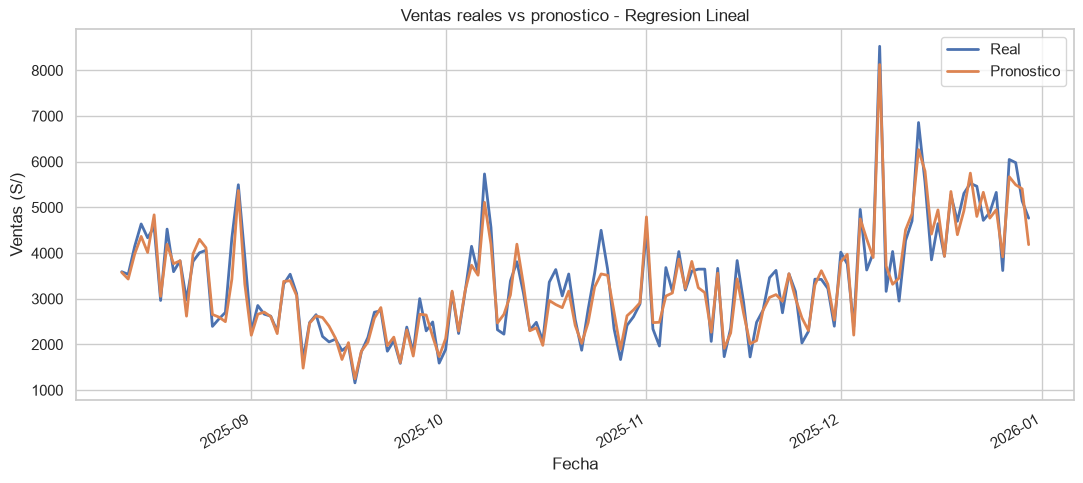

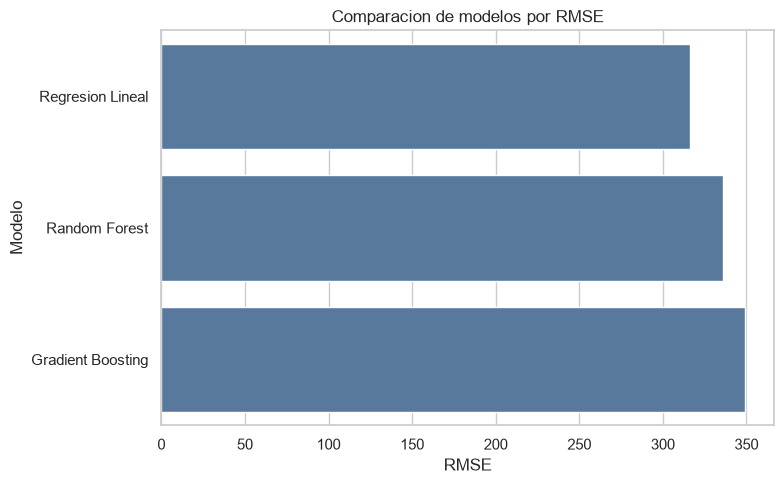

In [6]:
mejor_modelo_nombre = metricas_df.iloc[0]['modelo']
mejor_modelo = modelos[mejor_modelo_nombre]
test_result = test[['fecha', 'ventas']].copy()
test_result['pronostico'] = predicciones[mejor_modelo_nombre]
test_result['error'] = test_result['ventas'] - test_result['pronostico']
test_result['abs_error'] = test_result['error'].abs()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_result['fecha'], test_result['ventas'], label='Real', linewidth=2)
ax.plot(test_result['fecha'], test_result['pronostico'], label='Pronostico', linewidth=2)
ax.set_title(f'Ventas reales vs pronostico - {mejor_modelo_nombre}')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (S/)')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(IMG / 'regresion_real_vs_pronostico.png', dpi=140)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=metricas_df, x='RMSE', y='modelo', ax=ax, color='#4C78A8')
ax.set_title('Comparacion de modelos por RMSE')
ax.set_xlabel('RMSE')
ax.set_ylabel('Modelo')
fig.tight_layout()
fig.savefig(IMG / 'regresion_metricas_modelos.png', dpi=140)

test_result.head()

## 6. Pronostico de los siguientes 30 dias

Para el periodo futuro se usa una estrategia recursiva simple: los rezagos se alimentan con ventas reales recientes y pronosticos previos. Las variables operativas futuras como demanda, boletas y promociones se aproximan con promedios moviles recientes.

In [7]:
mejor_modelo.fit(model_df[features], model_df['ventas'])

hist = df[['fecha', 'ventas', 'demanda', 'pct_lineas_promocion', 'boletas']].copy()
futuros = []
ultima_fecha = hist['fecha'].max()

for paso in range(1, 31):
    fecha = ultima_fecha + pd.Timedelta(days=paso)
    temp = pd.concat([hist, pd.DataFrame(futuros)], ignore_index=True)
    fila = {
        'fecha': fecha,
        'demanda': temp['demanda'].tail(28).mean(),
        'pct_lineas_promocion': temp['pct_lineas_promocion'].tail(28).mean(),
        'boletas': temp['boletas'].tail(28).mean(),
        'dia_semana': fecha.dayofweek,
        'mes': fecha.month,
        'trimestre': fecha.quarter,
        'dia_mes': fecha.day,
        'semana_anio': int(fecha.isocalendar().week),
        'es_fin_semana': int(fecha.dayofweek in [5, 6]),
        'es_mes_alto': int(fecha.month in [7, 12]),
    }
    for lag in [1, 7, 14, 28]:
        fila[f'lag_{lag}'] = temp['ventas'].iloc[-lag]
    for ventana in [7, 14, 28]:
        fila[f'rolling_{ventana}'] = temp['ventas'].tail(ventana).mean()

    pred = float(mejor_modelo.predict(pd.DataFrame([fila])[features])[0])
    fila['ventas'] = max(pred, 0)
    futuros.append(fila)

pronostico_futuro = pd.DataFrame(futuros)
pronostico_futuro[['fecha', 'ventas']].head()

,fecha,ventas
0,2025-12-31,4853.615880
1,2026-01-01,4752.559008
2,2026-01-02,4779.231390
3,2026-01-03,4838.891586
4,2026-01-04,4745.913694


## 7. Exportacion para Power BI

In [8]:
real_vs_pronostico = test_result.copy()
real_vs_pronostico['tipo'] = 'validacion'
real_vs_pronostico['modelo'] = mejor_modelo_nombre

futuro_export = pronostico_futuro[['fecha', 'ventas']].rename(columns={'ventas': 'pronostico'})
futuro_export['ventas'] = np.nan
futuro_export['error'] = np.nan
futuro_export['abs_error'] = np.nan
futuro_export['tipo'] = 'futuro'
futuro_export['modelo'] = mejor_modelo_nombre

pronostico_export = pd.concat([
    real_vs_pronostico[['fecha', 'ventas', 'pronostico', 'error', 'abs_error', 'tipo', 'modelo']],
    futuro_export[['fecha', 'ventas', 'pronostico', 'error', 'abs_error', 'tipo', 'modelo']],
], ignore_index=True)

metricas_df.to_csv(DATA / 'metricas_regresion.csv', sep=';', index=False, encoding='utf-8')
pronostico_export.to_csv(DATA / 'pronostico_ventas.csv', sep=';', index=False, encoding='utf-8')

md = '# Resumen de regresion - pronostico de ventas\n\n'
md += '- Objetivo: ventas diarias agregadas.\n'
md += '- Validacion: division temporal 80% entrenamiento y 20% prueba.\n'
md += f'- Mejor modelo: {mejor_modelo_nombre}.\n'
best = metricas_df.iloc[0]
md += f"- MAE: {best['MAE']:.2f}; RMSE: {best['RMSE']:.2f}; MAPE: {best['MAPE']:.2f}%; R2: {best['R2']:.3f}.\n\n"
md += '## Interpretacion de negocio\n\n'
md += 'El pronostico permite anticipar ventas esperadas, ajustar inventario y planificar campanas. El error debe monitorearse especialmente en meses con estacionalidad alta como julio y diciembre.\n'

(ROOT / 'informe' / 'resumen_regresion.md').write_text(md, encoding='utf-8')
pronostico_export.head()

,fecha,ventas,pronostico,error,abs_error,tipo,modelo
0,2025-08-12,3592.2500,3576.830234,15.419766,15.419766,validacion,Regresion Lineal
1,2025-08-13,3534.7300,3431.450525,103.279475,103.279475,validacion,Regresion Lineal
2,2025-08-14,4147.2445,3979.417911,167.826589,167.826589,validacion,Regresion Lineal
3,2025-08-15,4638.1305,4365.214558,272.915942,272.915942,validacion,Regresion Lineal
4,2025-08-16,4335.3380,4013.544127,321.793873,321.793873,validacion,Regresion Lineal


## 8. Salidas generadas

- `data/processed/pronostico_ventas.csv`: ventas reales vs pronostico y 30 dias futuros.
- `data/processed/metricas_regresion.csv`: comparacion de modelos.
- `informe/resumen_regresion.md`: interpretacion y recomendaciones.
- Imagenes en `informe/img/`: real vs pronostico y comparacion de modelos.